### Why Transformation is Needed?
Many classical ML models **assume**:
- Symmetric distributions
- Linear relationships
- Homoscedastic variance

Real data:
- Right-skewed
- Long-tailed
- Heteroscedastic

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

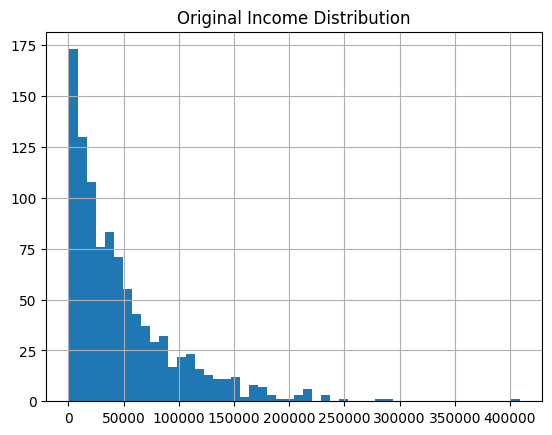

In [2]:
np.random.seed(42)

df = pd.DataFrame({
    "income": np.random.exponential(scale=50000, size=1000)
})

df["income"].hist(bins=50)
plt.title("Original Income Distribution")
plt.show()


**Observations:**
- Long right tail
- Mean ≠ Median
- Extreme values

### 1. Log Transformation 
#### When to Use
- Right-skewed data
- Positive values
- Financial, count-like features

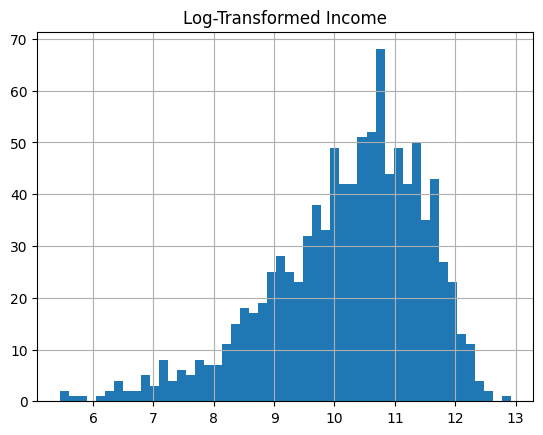

In [3]:
df["income_log"] = np.log1p(df["income"])

df["income_log"].hist(bins=50)
plt.title("Log-Transformed Income")
plt.show()

Why `log1p`?
- Handles zero safely
- Numerically stable

### 2. Square Root Transformation
#### Use Case
- Mild skew
- Count data

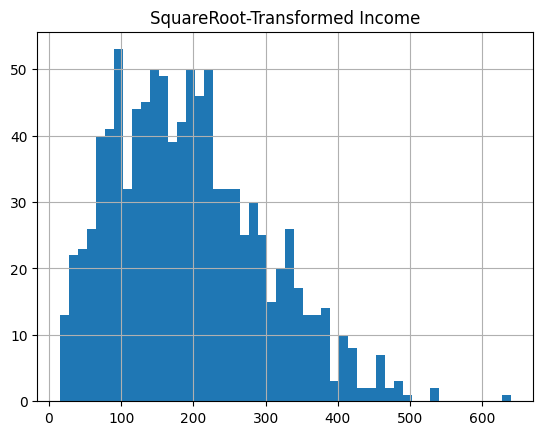

In [4]:
df["income_sqrt"] = np.sqrt(df["income"])

df["income_sqrt"].hist(bins=50)
plt.title("SquareRoot-Transformed Income")
plt.show()

Less aggressive than log

### 3. Reciprocal Transformation (Rare but Useful)

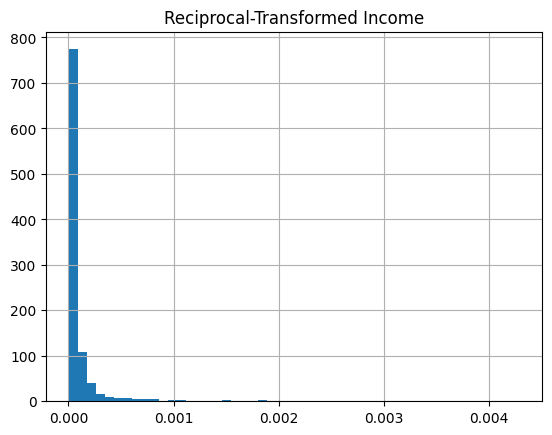

In [5]:
df["income_inv"] = 1 / (df["income"] + 1)

df["income_inv"].hist(bins=50)
plt.title("Reciprocal-Transformed Income")
plt.show()

- Extreme tail compression
- Hard to interpret

### 4. Power Transformations (Advanced and Powerful)
#### 4.1 Box-Cox Transformation
Box-Cox automatically finds the best power ($\lambda$):  
$
x' = \begin{cases}
\frac{x^{\lambda} - 1}{\lambda}, & {\lambda} \neq 0 \\
log(x), & {\lambda} = 0
\end{cases}
$   

All values must be **positive**

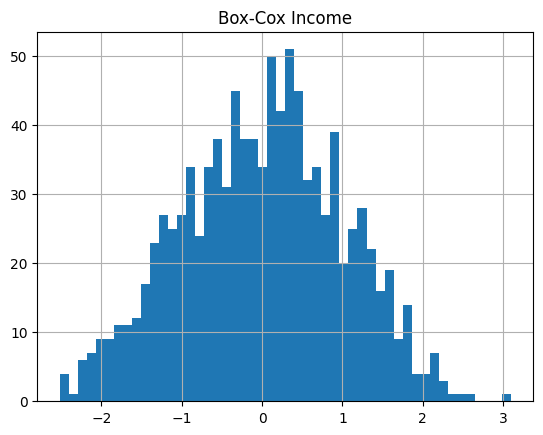

In [6]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="box-cox")
df["income_boxcox"] = pt.fit_transform(df[["income"]])

df["income_boxcox"].hist(bins=50)
plt.title("Box-Cox Income")
plt.show()

#### 4.2 Yeo-Johnson Transformation
Extension of Box-Cox that suppports:
- Zero
- Negative values

$
x' = \begin{cases}
\frac{(x + 1)^{\lambda} - 1}{\lambda}, & x \ge 0, & {\lambda} \neq 0 \\
log(x + 1), & x \ge 0, & {\lambda} = 0 \\
-\frac{(-x + 1)^{2-{\lambda}} - 1}{2 - {\lambda}}, & x \lt 0, & {\lambda} \ne 2 \\
-log(-x + 1), & x \lt 0, & {\lambda} = 2
\end{cases}
$  

| λ value | Effect                                        |
| ------- | --------------------------------------------- |
| λ = 1   | No transformation                             |
| λ = 0   | Log-like transformation (for positive values) |
| λ < 1   | Reduces right skew                            |
| λ > 1   | Reduces left skew                             |


Often outperfoms manual log transforms.

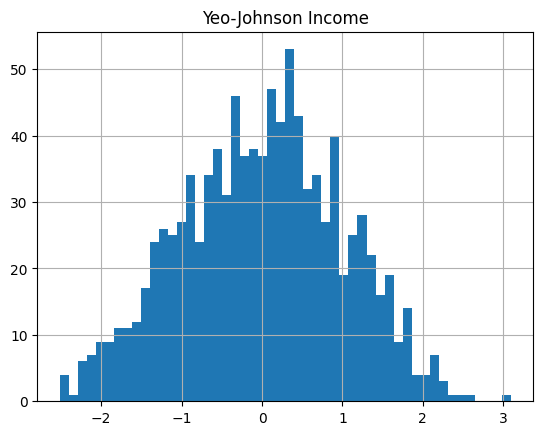

In [7]:
pt = PowerTransformer(method="yeo-johnson")
df["income_yeojohnson"] = pt.fit_transform(df[["income"]])

df["income_yeojohnson"].hist(bins=50)
plt.title("Yeo-Johnson Income")
plt.show()

### 5. Transforming the Target Variable (Regression)

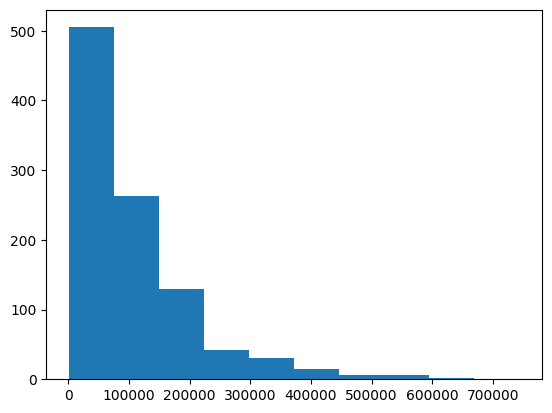

In [8]:
y = np.random.exponential(scale=100000, size=1000)

plt.hist(y)
plt.show()

y_log = np.log1p(y)

- Stabilizes variance
- Improves RMSE
- Needs inverse transform during inference

### 6. Skewness Before vs After

In [9]:
df["income"].skew(), df["income_log"].skew()

(np.float64(1.867837146801098), np.float64(-0.8323581755168281))

Goal: skewness -> closer to 0

### 7. Transformation vs Scaling
| Transformation   | Scaling             |
| ---------------- | ------------------- |
| Changes shape    | Changes magnitude   |
| Fixes skew       | Equalizes influence |
| Model assumption | Model math          |

Often used **together**

### 8. Algorithm Awareness
| Algorithm           | Benefit               |
| ------------------- | --------------------- |
| Linear Regression   | Huge               |
| Logistic Regression | Huge               |
| KNN / SVM           | Moderate           |
| Decision Trees      | Usually unnecessary |
| Random Forest       | Usually unnecessary |
